<a href="https://colab.research.google.com/github/kartikeyabekkari/HyperRealisticNisqSimulation/blob/main/Hyper_Realistic_NISQ_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Setup & Imports



In [ ]:
!pip install --upgrade --force-reinstall cirq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 733.7/733.7 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.5/176.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [9]:
import warnings
warnings.filterwarnings("ignore")


try:
    import cirq
except ImportError:
    print("installing cirq...")
    !pip install cirq --quiet
    import cirq
    print("installed cirq.")


import matplotlib.pyplot as plt
import cirq_web
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random
deg = np.radians

print("Libraries Imported Successfully!")

Libraries Imported Successfully!




---


#Parameters





In [10]:
import cirq
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random
deg = np.radians

---
#Divider
---

In [18]:
#================= Parameters =================

number_of_qubits_in_the_circuit = 2
number_of_runs = 2000
distance_between_qubits = 2  # micrometers

base_noise = 0.00001

single_qubit_noise = 0.00036
single_qubit_plus_minus = 0.00029

multi_qubit_noise = 0.0033
multi_qubit_plus_minus = 0.0018

readout_noise = 0.0077
readout_noise_plus_minus = 0.0021

amplitude_damp_chance = 0.00092647
#================= Build Circuit =================
qubits = cirq.LineQubit.range(number_of_qubits_in_the_circuit)
base_circuit = cirq.Circuit([
#-------------------------------------------------
cirq.H(qubits[0]),
cirq.CNOT(qubits[0],qubits[1]),
cirq.measure(qubits, key='result'),
#------------------ Edit Here ^ ------------------
])

print(f"Your Circuit:\n\n{base_circuit}\n")

Your Circuit:

0: ───H───@───M('result')───
          │   │
1: ───────X───M─────────────



---
#Functions
---

In [19]:
from cirq.ops.parity_gates import YYPowGate
SINGLE_GATE_TYPES = (
    cirq.XPowGate,
    cirq.YPowGate,
    cirq.ZPowGate,
    cirq.HPowGate,
)
MULTI_GATE_TYPES = (
    cirq.CXPowGate,
    cirq.CYPowGate,
    cirq.CZPowGate,
    cirq.XXPowGate,
    cirq.YYPowGate,
    cirq.ZZPowGate,
    cirq.CCNotPowGate,
    cirq.CCXPowGate,
    cirq.CCYPowGate,
    cirq.CCZPowGate,
    cirq.ISwapPowGate,
    cirq.SwapPowGate,
)

#---------- error values for each type of gate ----------
readout_error_nums = [(max(0,readout_noise-readout_noise_plus_minus)),readout_noise,(min(1,readout_noise+readout_noise_plus_minus))]
multi_gate_error_nums = [(max(0, multi_qubit_noise-multi_qubit_plus_minus)),multi_qubit_noise,(min(1,multi_qubit_noise+multi_qubit_plus_minus))] # Ensured the lower bound is not negative
single_gate_error_nums = [(max(0,single_qubit_noise-single_qubit_plus_minus)),single_qubit_noise,(min(1,single_qubit_noise+single_qubit_plus_minus))]

def build_shot_circuit(original_circuit, all_qubits):
    circuit = cirq.Circuit()

    num_moments = len(original_circuit)

    for i, moment in enumerate(original_circuit):
        circuit.append(moment)

        if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
            continue

        single_loud_qubits = {
            q for op in moment if isinstance(op.gate, SINGLE_GATE_TYPES) for q in op.qubits}
        multi_loud_qubits = {
            q for op in moment if isinstance(op.gate, MULTI_GATE_TYPES) for q in op.qubits}

        bit_flip_ops = []
        depolarize_ops = []
        flipped_qubit_indices = []

        for q_idx, q in enumerate(all_qubits):
            if q in multi_loud_qubits:
              error_rate = random.choice(multi_gate_error_nums)
            elif q in single_loud_qubits:
              error_rate = random.choice(single_gate_error_nums)
            else:
              error_rate = base_noise

            bit_flip_ops.append(cirq.bit_flip(p=error_rate)(q))
            depolarize_ops.append(cirq.depolarize(p=error_rate)(q))

            if np.random.rand() < error_rate:
                flipped_qubit_indices.append(q_idx)

        #circuit.append(cirq.Moment(bit_flip_ops))
        circuit.append(cirq.Moment(depolarize_ops))
        circuit.append(cirq.Moment(cirq.amplitude_damp(amplitude_damp_chance)(q) for q in all_qubits))

        # --- Crosstalk made with the flip idx above ---

        crosstalk_ops = []
        for q_idx, q in enumerate(all_qubits):
            if q_idx in flipped_qubit_indices:
                crosstalk_p = 1.0  # this qubit already flipped, therefore treat as certain
            elif flipped_qubit_indices:
                distance = [
                    abs(q_idx - flipped_idx) * distance_between_qubits for flipped_idx in flipped_qubit_indices]
                shortest_distance = min(distance)



                crosstalk_p = 1.0 / (shortest_distance*distance_between_qubits ** 4)  # Needs edits



            else:
              # no flip happend in the whole moment, no opportunity for crosstalk
                crosstalk_p = 0.0

            crosstalk_ops.append(cirq.bit_flip(p=crosstalk_p)(q))
        circuit.append(cirq.Moment(crosstalk_ops))


        if i == num_moments - 2:
            circuit.append(cirq.bit_flip(random.choice(readout_error_nums)).on_each(qubits))

    return circuit
# ================= Simulate + collect results =================
total_counts = Counter()


def simulate(circuit, type_of_noise=None):
    #Runs circuit once (1 shot) and adds the result into total_counts
    sim = cirq.Simulator()
    result = sim.run(circuit)
    total_counts.update(result.histogram(key='result'))


def graph(num_qubits, num_runs):
    # Creates bar chart
    print("\n--- SIMULATION RESULTS ---\n")

    total_possible_states = 2 ** num_qubits
    labels, values = [], []
    for outcome in range(total_possible_states):
        binary_string = format(outcome, f"0{num_qubits}b")
        labels.append(binary_string)
        actual_count = total_counts.get(outcome, 0)
        values.append(actual_count)
        print(f"State |{binary_string}⟩: {actual_count} times ~ {(actual_count / num_runs) * 100:.2f}%")

    plt.figure(figsize=(1 + 2 * num_qubits, 6))
    plt.bar(labels, values, color="lightblue", edgecolor="lightblue")
    plt.title(f"Total For {num_runs} Procedural Runs")
    plt.xlabel("Quantum States")
    plt.ylabel("Total Count")
    plt.xticks(rotation=315, fontsize=8)
    plt.grid(axis="y", linestyle="--", alpha=0.85)
    plt.tight_layout()
    plt.show()


def run_NISQ_simulation(circuit_template, all_qubits, num_runs):
    # defines how to run
    total_counts.clear()
    print(f'Circuit:\n{base_circuit}')
    for _ in range(num_runs):
        shot_circuit = build_shot_circuit(circuit_template, all_qubits)
        #print(f'{shot_circuit}\n\n\n')
        simulate(shot_circuit)
    graph(len(all_qubits), num_runs)

---
# Run the circuit
---

Circuit:
0: ───H───@───M('result')───
          │   │
1: ───────X───M─────────────

--- SIMULATION RESULTS ---

State |00⟩: 9 times ~ 45.00%
State |01⟩: 0 times ~ 0.00%
State |10⟩: 1 times ~ 5.00%
State |11⟩: 10 times ~ 50.00%


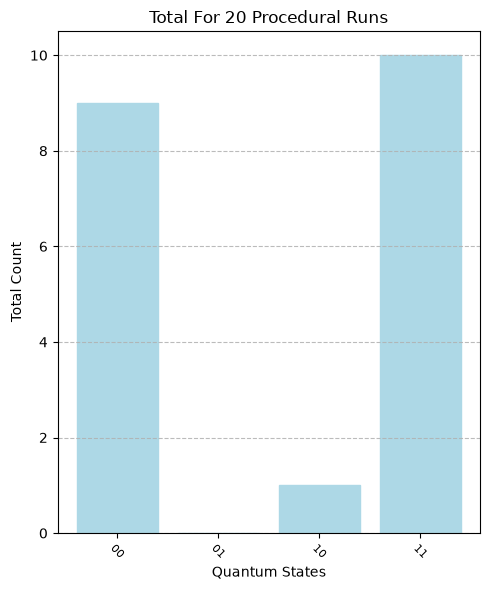

In [20]:
run_NISQ_simulation(base_circuit, qubits, 20)

#
---

#Divider 2


In [27]:
from __future__ import annotations

from dataclasses import dataclass

import cirq
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

LOUD_GATE_TYPES = (
    cirq.XPowGate,
    cirq.YPowGate,
    cirq.ZPowGate,
    cirq.HPowGate,
    cirq.CXPowGate,
    cirq.PhasedXPowGate,
)

# Fixes every source of randomness in this script (data generation, the
# train/holdout split, class balancing, and the classifier itself) so
# re-running produces the SAME result every time instead of a different
# one. Change this value if you deliberately want to test a different
# random realization.
RANDOM_SEED = 45


@dataclass
class NoiseConfig:
    name: str
    base_noise: float          # background error rate on idle qubits
    high_noise: float          # error rate on actively-driven qubits
    amplitude_damp_chance: float
    distance_between_qubits: float  # micrometers; smaller = stronger crosstalk


# "Low error percentage" baseline -- bulk of the training data.
LOW_NOISE_CONFIG = NoiseConfig(
    name="low_noise_baseline",
    base_noise=0.00005,
    high_noise=0.0002,
    amplitude_damp_chance=0.00002,
    distance_between_qubits=4,
)

# Higher, more realistic error rates -- mimics an actual NISQ device.
# Placeholder scale-up until calibrated against real hardware data.
REAL_WORLD_CONFIG = NoiseConfig(
    name="real_world_nisq",
    base_noise=0.02,
    high_noise=0.1,
    amplitude_damp_chance=0.001,
    distance_between_qubits=2,
)


# ================= Noise + crosstalk model (same as nisq_corrected.py) =================
def build_shot_circuit(original_circuit, all_qubits, config: NoiseConfig):
    """Builds one noisy shot circuit under the given NoiseConfig."""
    circuit = cirq.Circuit()
    for moment in original_circuit:
        circuit.append(moment)
        if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
            continue

        active_loud_qubits = {
            q for op in moment if isinstance(op.gate, LOUD_GATE_TYPES) for q in op.qubits
        }

        bit_flip_ops, depolarize_ops, flipped_qubit_indices = [], [], []
        for q_idx, q in enumerate(all_qubits):
            rate = config.high_noise if q in active_loud_qubits else config.base_noise
            bit_flip_ops.append(cirq.bit_flip(p=rate)(q))
            depolarize_ops.append(cirq.depolarize(p=rate)(q))
            if np.random.rand() < rate:
                flipped_qubit_indices.append(q_idx)

        #circuit.append(cirq.Moment(bit_flip_ops))
        circuit.append(cirq.Moment(depolarize_ops))
        circuit.append(cirq.Moment(cirq.amplitude_damp(config.amplitude_damp_chance)(q) for q in all_qubits))

        crosstalk_ops = []
        for q_idx, q in enumerate(all_qubits):
            if q_idx in flipped_qubit_indices:
                crosstalk_p = 1.0
            elif flipped_qubit_indices:
                distances = [
                    abs(q_idx - flipped_idx) * config.distance_between_qubits
                    for flipped_idx in flipped_qubit_indices
                ]
                shortest = max(min(distances), 1e-9)
                crosstalk_p = min(1.0, 1.0 / (shortest ** 2))
            else:
                crosstalk_p = 0.0
            crosstalk_ops.append(cirq.bit_flip(p=crosstalk_p)(q))
        circuit.append(cirq.Moment(crosstalk_ops))

    return circuit


# ================= Dataset generation =================
def generate_dataset(base_circuit, qubits, config: NoiseConfig, num_samples: int, ideal_simulator=None):
    """
    Returns (X, y):
      X = [base_noise, high_noise, amplitude_damp_chance, distance_between_qubits, *noisy_bitstring]
      y = ideal_bitstring (ground truth, from the noiseless circuit)

    Note: the bitstrings here have as many bits as are actually measured
    by `base_circuit` (its `cirq.measure(..., key='result')` operation),
    which is NOT necessarily the same as len(qubits) -- a circuit can use
    extra "helper" qubits internally that are never measured.
    """
    ideal_simulator = ideal_simulator or cirq.Simulator()
    noisy_simulator = cirq.Simulator()
    config_features = [
        config.base_noise,
        config.high_noise,
        config.amplitude_damp_chance,
        config.distance_between_qubits,
    ]

    X_rows, y_rows = [], []
    for _ in range(num_samples):
        shot_circuit = build_shot_circuit(base_circuit, qubits, config)
        noisy_bits = noisy_simulator.run(shot_circuit).measurements['result'][0]
        ideal_bits = ideal_simulator.run(base_circuit).measurements['result'][0]

        X_rows.append(config_features + list(noisy_bits))
        y_rows.append(list(ideal_bits))

    return np.array(X_rows, dtype=float), np.array(y_rows, dtype=float)


def bitstring_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Fraction of samples where EVERY bit matches the ideal bitstring."""
    return float(np.mean(np.all(y_true == y_pred, axis=1)))


def per_bit_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    """Per-qubit accuracy, useful for seeing which qubits are hardest to correct."""
    return np.mean(y_true == y_pred, axis=0)


def bits_to_state_indices(bit_rows: np.ndarray) -> np.ndarray:
    """Converts an (N, num_qubits) array of 0/1 rows into an (N,) array of integer state indices."""
    num_qubits = bit_rows.shape[1]
    weights = 2 ** np.arange(num_qubits - 1, -1, -1)
    return bit_rows.astype(int).dot(weights)


def state_indices_to_bits(state_indices: np.ndarray, num_qubits: int) -> np.ndarray:
    """Inverse of bits_to_state_indices: turns integer class labels back into 0/1 bit rows."""
    rows = [[int(b) for b in format(int(idx), f"0{num_qubits}b")] for idx in state_indices]
    return np.array(rows, dtype=float)


def balance_classes(X: np.ndarray, y_labels: np.ndarray, random_state: int = 0) -> tuple[np.ndarray, np.ndarray]:
    """
    Oversamples (with replacement) every class up to the size of the
    largest class, so the model can't learn "predict the more common
    outcome" as a shortcut. Without this, whichever ideal state happens
    to be slightly more frequent in a given (unseeded) data-generation
    run gets treated as the default answer, which is what causes the
    asymmetric over/under-correction between |0000> and |1111>.
    """
    rng = np.random.default_rng(random_state)
    unique_labels, counts = np.unique(y_labels, return_counts=True)
    target_count = counts.max()

    balanced_idx = []
    for label in unique_labels:
        idx_for_label = np.where(y_labels == label)[0]
        sampled_idx = rng.choice(idx_for_label, size=target_count, replace=True)
        balanced_idx.append(sampled_idx)
    balanced_idx = np.concatenate(balanced_idx)
    rng.shuffle(balanced_idx)

    return X[balanced_idx], y_labels[balanced_idx]


def plot_before_after_histograms(y_ideal: np.ndarray, y_noisy: np.ndarray, y_corrected: np.ndarray, num_qubits: int):
    """
    Side-by-side histograms over every computational basis state,
    comparing the ideal distribution against the raw noisy results
    (before correction) and the ML-corrected results (after correction).
    Same y-axis scale on both so the improvement is visually comparable.
    """
    num_states = 2 ** num_qubits
    labels = [format(i, f"0{num_qubits}b") for i in range(num_states)]

    ideal_counts = np.bincount(bits_to_state_indices(y_ideal), minlength=num_states)
    noisy_counts = np.bincount(bits_to_state_indices(y_noisy), minlength=num_states)
    corrected_counts = np.bincount(bits_to_state_indices(y_corrected), minlength=num_states)

    y_max = max(ideal_counts.max(), noisy_counts.max(), corrected_counts.max()) * 1.15
    x = np.arange(num_states)
    width = 0.35

    fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    ax_before.bar(x - width / 2, ideal_counts, width, label="Ideal", color="gray", alpha=0.6)
    ax_before.bar(x + width / 2, noisy_counts, width, label="Raw noisy", color="lightcoral", edgecolor="black")
    ax_before.set_title("Before correction")
    ax_before.set_xlabel("Quantum state")
    ax_before.set_ylabel("Count")
    ax_before.set_xticks(x)
    ax_before.set_xticklabels(labels, rotation=315, fontsize=8)
    ax_before.set_ylim(0, y_max)
    ax_before.legend()
    ax_before.grid(axis="y", linestyle="--", alpha=0.6)

    ax_after.bar(x - width / 2, ideal_counts, width, label="Ideal", color="gray", alpha=0.6)
    ax_after.bar(x + width / 2, corrected_counts, width, label="ML-corrected", color="lightgreen", edgecolor="black")
    ax_after.set_title("After correction")
    ax_after.set_xlabel("Quantum state")
    ax_after.set_xticks(x)
    ax_after.set_xticklabels(labels, rotation=315, fontsize=8)
    ax_after.legend()
    ax_after.grid(axis="y", linestyle="--", alpha=0.6)

    fig.suptitle("Outcome distribution vs. ideal: before vs. after ML error correction\n(real-world-noise held-out test set)")
    plt.tight_layout()
    plt.show()


# ================= Main training + evaluation pipeline =================
def main():
    np.random.seed(RANDOM_SEED)  # makes data generation, noise draws, and sampling reproducible



    print(f'your circuit \n\n{base_circuit}\n')
    ideal_sim = cirq.Simulator()

    # IMPORTANT FIX: `number_of_qubits` (3) is how many qubits the circuit
    # USES internally (qubit 2 is an unmeasured helper qubit), but the
    # `cirq.measure(...)` call above only measures qubits 0 and 1. Every
    # bitstring coming out of generate_dataset() is therefore only
    # `num_measured_qubits`-wide, NOT `number_of_qubits`-wide. Mixing the
    # two up is what caused:
    #   ValueError: operands could not be broadcast together with shapes (1000,2) (1000,3)
    # so we derive the measured-qubit count directly from the circuit and
    # use THAT (not number_of_qubits) everywhere a bitstring shape matters.
    measured_qubits = [
        q for op in base_circuit.all_operations()
        if isinstance(op.gate, cirq.MeasurementGate)
        for q in op.qubits
    ]
    num_measured_qubits = len(measured_qubits)

    print("Generating LOW-noise training data (clean baseline)...")
    X_low, y_low = generate_dataset(base_circuit, qubits, LOW_NOISE_CONFIG, num_samples=2400, ideal_simulator=ideal_sim)

    print("Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...")
    X_real_train, y_real_train = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, num_samples=600, ideal_simulator=ideal_sim)

    print("Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...")
    X_real_test, y_real_test = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, num_samples=1000, ideal_simulator=ideal_sim)

    # Training set: mostly low-noise (the "low error percentage" data),
    # with a smaller slice of real-world-noise data mixed in so the model
    # has at least seen the harder error regime it'll be evaluated on.
    X_train = np.vstack([X_low, X_real_train])
    y_train = np.vstack([y_low, y_real_train])
    # Stratify by joint outcome state so the train/holdout split preserves
    # whatever class balance the generated data has, instead of letting
    # an unstratified random split shift it further.
    y_train_labels_full = bits_to_state_indices(y_train)
    X_train, X_holdout, y_train, y_holdout = train_test_split(
        X_train, y_train, test_size=0.15, random_state=0, stratify=y_train_labels_full
    )

    print(f"\nTraining samples: {len(X_train)}  (holdout: {len(X_holdout)}, real-world test: {len(X_real_test)})")

    print("Training MLP error-mitigation model...")
    # IMPORTANT: this circuit's ideal outcomes are perfectly correlated
    # across qubits -- so instead of training independent per-bit
    # classifiers (which have no way to know the bits are linked, and
    # whose small individual biases compound into wildly overcorrecting
    # toward one state), we train ONE classifier over the joint outcome
    # state. This lets the model learn the correct *proportional*
    # asymmetry from the noise model (e.g. amplitude damping only ever
    # pulling 1->0) instead of an all-or-nothing collapse.
    y_train_labels = bits_to_state_indices(y_train)

    # Balance classes so no single outcome is treated as the "default"
    # answer just because it happened to be slightly more common in this
    # (unseeded) data-generation run.
    X_train_balanced, y_train_labels_balanced = balance_classes(X_train, y_train_labels)

    model = make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=0),
    )
    model.fit(X_train_balanced, y_train_labels_balanced)

    # --- Evaluate on the held-out real-world test set ---
    # FIX: slice off the last `num_measured_qubits` columns (not
    # `number_of_qubits`) since that's how many bits were actually measured.
    noisy_bits_test = X_real_test[:, -num_measured_qubits:]
    raw_acc = bitstring_accuracy(y_real_test, noisy_bits_test)

    corrected_labels_test = model.predict(X_real_test)
    # FIX: reconstruct bitstrings using num_measured_qubits, matching the
    # width of y_real_test.
    corrected_bits_test = state_indices_to_bits(corrected_labels_test, num_measured_qubits)
    corrected_acc = bitstring_accuracy(y_real_test, corrected_bits_test)

    raw_per_bit = per_bit_accuracy(y_real_test, noisy_bits_test)
    corrected_per_bit = per_bit_accuracy(y_real_test, corrected_bits_test)

    print("\n=== Real-world NISQ evaluation (held-out test set) ===")
    print(f"Raw noisy bitstring accuracy:       {raw_acc * 100:.2f}%")
    print(f"Model-corrected bitstring accuracy: {corrected_acc * 100:.2f}%")
    print(f"Improvement:                        {(corrected_acc - raw_acc) * 100:+.2f} percentage points\n")
    for i in range(num_measured_qubits):
        print(f"  qubit {i}: raw={raw_per_bit[i] * 100:5.2f}%  corrected={corrected_per_bit[i] * 100:5.2f}%")

    # --- Plots ---
    plot_before_after_histograms(y_real_test, noisy_bits_test, corrected_bits_test, num_measured_qubits)

    plt.figure(figsize=(5, 5))
    plt.bar(["Raw noisy", "ML-corrected"], [raw_acc * 100, corrected_acc * 100],
            color=["lightcoral", "lightgreen"], edgecolor="black")
    plt.ylabel("Full-bitstring accuracy vs. ideal (%)")
    plt.title("Error mitigation: raw vs. ML-corrected\n(evaluated on real-world-noise test set)")
    plt.ylim(0, 100)
    for i, v in enumerate([raw_acc * 100, corrected_acc * 100]):
        plt.text(i, v + 1, f"{v:.1f}%", ha="center")
    plt.tight_layout()
    plt.show()

your circuit 

0: ───H───@───M('result')───
          │   │
1: ───────X───M─────────────

Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...
Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...

Training samples: 2550  (holdout: 450, real-world test: 1000)
Training MLP error-mitigation model...

=== Real-world NISQ evaluation (held-out test set) ===
Raw noisy bitstring accuracy:       38.70%
Model-corrected bitstring accuracy: 49.00%
Improvement:                        +10.30 percentage points

  qubit 0: raw=52.00%  corrected=49.00%
  qubit 1: raw=50.90%  corrected=49.00%


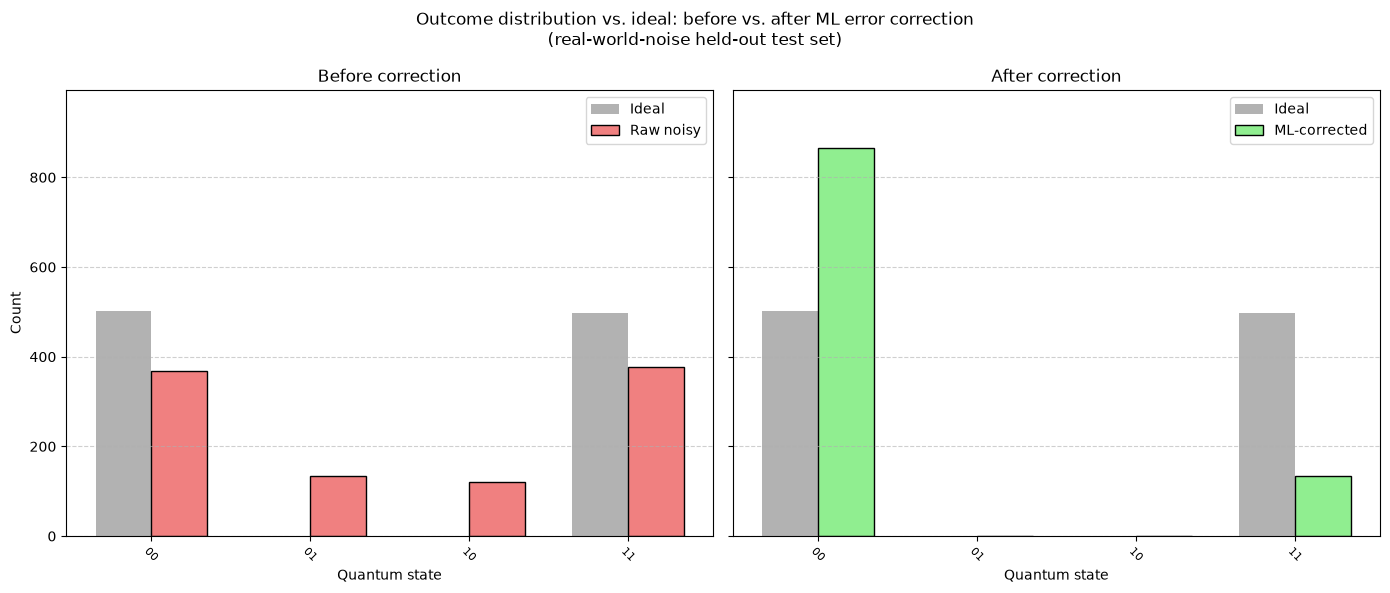

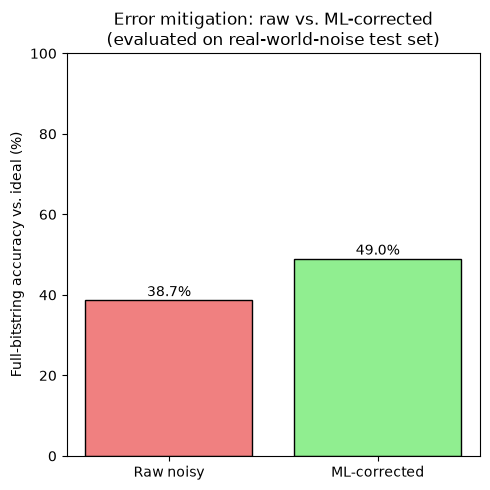

In [28]:
main()

#

In [1]:

from __future__ import annotations

from dataclasses import dataclass

import cirq
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

LOUD_GATE_TYPES = (
    cirq.XPowGate,
    cirq.YPowGate,
    cirq.ZPowGate,
    cirq.HPowGate,
    cirq.CXPowGate,
    cirq.PhasedXPowGate,
)

# Fixes every source of randomness in this script (data generation, the
# train/holdout split, class balancing, and the classifier itself) so
# re-running produces the SAME result every time instead of a different
# one. Change this value if you deliberately want to test a different
# random realization.
RANDOM_SEED = 42


@dataclass
class NoiseConfig:
    name: str
    base_noise: float          # background error rate on idle qubits
    high_noise: float          # error rate on actively-driven qubits
    amplitude_damp_chance: float
    distance_between_qubits: float  # micrometers; smaller = stronger crosstalk


# "Low error percentage" baseline -- bulk of the training data.
LOW_NOISE_CONFIG = NoiseConfig(
    name="low_noise_baseline",
    base_noise=0.00005,
    high_noise=0.0002,
    amplitude_damp_chance=0.00002,
    distance_between_qubits=4,
)

# Higher, more realistic error rates -- mimics an actual NISQ device.
# Placeholder scale-up until calibrated against real hardware data.
REAL_WORLD_CONFIG = NoiseConfig(
    name="real_world_nisq",
    base_noise=0.02,
    high_noise=0.1,
    amplitude_damp_chance=0.001,
    distance_between_qubits=2,
)


# ================= Noise + crosstalk model (same as nisq_corrected.py) =================
def build_shot_circuit(original_circuit, all_qubits, config: NoiseConfig):
    """Builds one noisy shot circuit under the given NoiseConfig."""
    circuit = cirq.Circuit()
    for moment in original_circuit:
        circuit.append(moment)
        if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
            continue

        active_loud_qubits = {
            q for op in moment if isinstance(op.gate, LOUD_GATE_TYPES) for q in op.qubits
        }

        bit_flip_ops, depolarize_ops, flipped_qubit_indices = [], [], []
        for q_idx, q in enumerate(all_qubits):
            rate = config.high_noise if q in active_loud_qubits else config.base_noise
            bit_flip_ops.append(cirq.bit_flip(p=rate)(q))
            depolarize_ops.append(cirq.depolarize(p=rate)(q))
            if np.random.rand() < rate:
                flipped_qubit_indices.append(q_idx)

        #circuit.append(cirq.Moment(bit_flip_ops))
        circuit.append(cirq.Moment(depolarize_ops))
        circuit.append(cirq.Moment(cirq.amplitude_damp(config.amplitude_damp_chance)(q) for q in all_qubits))

        crosstalk_ops = []
        for q_idx, q in enumerate(all_qubits):
            if q_idx in flipped_qubit_indices:
                crosstalk_p = 1.0
            elif flipped_qubit_indices:
                distances = [
                    abs(q_idx - flipped_idx) * config.distance_between_qubits
                    for flipped_idx in flipped_qubit_indices
                ]
                shortest = max(min(distances), 1e-9)
                crosstalk_p = min(1.0, 1.0 / (shortest ** 2))
            else:
                crosstalk_p = 0.0
            crosstalk_ops.append(cirq.bit_flip(p=crosstalk_p)(q))
        circuit.append(cirq.Moment(crosstalk_ops))

    return circuit


# ================= Dataset generation =================
def generate_dataset(base_circuit, qubits, config: NoiseConfig, num_samples: int, ideal_simulator=None):
    """
    Returns (X, y):
      X = [base_noise, high_noise, amplitude_damp_chance, distance_between_qubits, *noisy_bitstring]
      y = ideal_bitstring (ground truth, from the noiseless circuit)
    """
    ideal_simulator = ideal_simulator or cirq.Simulator()
    noisy_simulator = cirq.Simulator()
    config_features = [
        config.base_noise,
        config.high_noise,
        config.amplitude_damp_chance,
        config.distance_between_qubits,
    ]

    X_rows, y_rows = [], []
    for _ in range(num_samples):
        shot_circuit = build_shot_circuit(base_circuit, qubits, config)
        noisy_bits = noisy_simulator.run(shot_circuit).measurements['result'][0]
        ideal_bits = ideal_simulator.run(base_circuit).measurements['result'][0]

        X_rows.append(config_features + list(noisy_bits))
        y_rows.append(list(ideal_bits))

    return np.array(X_rows, dtype=float), np.array(y_rows, dtype=float)


def bitstring_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Fraction of samples where EVERY bit matches the ideal bitstring."""
    return float(np.mean(np.all(y_true == y_pred, axis=1)))


def per_bit_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    """Per-qubit accuracy, useful for seeing which qubits are hardest to correct."""
    return np.mean(y_true == y_pred, axis=0)


def bits_to_state_indices(bit_rows: np.ndarray) -> np.ndarray:
    """Converts an (N, num_qubits) array of 0/1 rows into an (N,) array of integer state indices."""
    num_qubits = bit_rows.shape[1]
    weights = 2 ** np.arange(num_qubits - 1, -1, -1)
    return bit_rows.astype(int).dot(weights)


def state_indices_to_bits(state_indices: np.ndarray, num_qubits: int) -> np.ndarray:
    """Inverse of bits_to_state_indices: turns integer class labels back into 0/1 bit rows."""
    rows = [[int(b) for b in format(int(idx), f"0{num_qubits}b")] for idx in state_indices]
    return np.array(rows, dtype=float)


def balance_classes(X: np.ndarray, y_labels: np.ndarray, random_state: int = 0) -> tuple[np.ndarray, np.ndarray]:
    """
    Oversamples (with replacement) every class up to the size of the
    largest class, so the model can't learn "predict the more common
    outcome" as a shortcut. Without this, whichever ideal state happens
    to be slightly more frequent in a given (unseeded) data-generation
    run gets treated as the default answer, which is what causes the
    asymmetric over/under-correction between |0000> and |1111>.
    """
    rng = np.random.default_rng(random_state)
    unique_labels, counts = np.unique(y_labels, return_counts=True)
    target_count = counts.max()

    balanced_idx = []
    for label in unique_labels:
        idx_for_label = np.where(y_labels == label)[0]
        sampled_idx = rng.choice(idx_for_label, size=target_count, replace=True)
        balanced_idx.append(sampled_idx)
    balanced_idx = np.concatenate(balanced_idx)
    rng.shuffle(balanced_idx)

    return X[balanced_idx], y_labels[balanced_idx]


def plot_before_after_histograms(y_ideal: np.ndarray, y_noisy: np.ndarray, y_corrected: np.ndarray, num_qubits: int):
    """
    Side-by-side histograms over every computational basis state (|0000>
    ... |1111>), comparing the ideal distribution against the raw noisy
    results (before correction) and the ML-corrected results (after
    correction). Same y-axis scale on both so the improvement is visually
    comparable.
    """
    num_states = 2 ** num_qubits
    labels = [format(i, f"0{num_qubits}b") for i in range(num_states)]

    ideal_counts = np.bincount(bits_to_state_indices(y_ideal), minlength=num_states)
    noisy_counts = np.bincount(bits_to_state_indices(y_noisy), minlength=num_states)
    corrected_counts = np.bincount(bits_to_state_indices(y_corrected), minlength=num_states)

    y_max = max(ideal_counts.max(), noisy_counts.max(), corrected_counts.max()) * 1.15
    x = np.arange(num_states)
    width = 0.35

    fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    ax_before.bar(x - width / 2, ideal_counts, width, label="Ideal", color="gray", alpha=0.6)
    ax_before.bar(x + width / 2, noisy_counts, width, label="Raw noisy", color="lightcoral", edgecolor="black")
    ax_before.set_title("Before correction")
    ax_before.set_xlabel("Quantum state")
    ax_before.set_ylabel("Count")
    ax_before.set_xticks(x)
    ax_before.set_xticklabels(labels, rotation=315, fontsize=8)
    ax_before.set_ylim(0, y_max)
    ax_before.legend()
    ax_before.grid(axis="y", linestyle="--", alpha=0.6)

    ax_after.bar(x - width / 2, ideal_counts, width, label="Ideal", color="gray", alpha=0.6)
    ax_after.bar(x + width / 2, corrected_counts, width, label="ML-corrected", color="lightgreen", edgecolor="black")
    ax_after.set_title("After correction")
    ax_after.set_xlabel("Quantum state")
    ax_after.set_xticks(x)
    ax_after.set_xticklabels(labels, rotation=315, fontsize=8)
    ax_after.legend()
    ax_after.grid(axis="y", linestyle="--", alpha=0.6)

    fig.suptitle("Outcome distribution vs. ideal: before vs. after ML error correction\n(real-world-noise held-out test set)")
    plt.tight_layout()
    plt.show()


# ================= Main training + evaluation pipeline =================
def main():
    np.random.seed(RANDOM_SEED)  # makes data generation, noise draws, and sampling reproducible

    number_of_qubits = 42
    qubits = cirq.LineQubit.range(number_of_qubits)
    base_circuit = cirq.Circuit([
        cirq.H(qubits[0]),
        cirq.CNOT(qubits[0], qubits[1]),
        cirq.measure(*qubits, key='result'),
    ])

    ideal_sim = cirq.Simulator()

    print("Generating LOW-noise training data (clean baseline)...")
    X_low, y_low = generate_dataset(base_circuit, qubits, LOW_NOISE_CONFIG, num_samples=2400, ideal_simulator=ideal_sim)

    print("Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...")
    X_real_train, y_real_train = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, num_samples=600, ideal_simulator=ideal_sim)

    print("Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...")
    X_real_test, y_real_test = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, num_samples=1000, ideal_simulator=ideal_sim)

    # Training set: mostly low-noise (the "low error percentage" data),
    # with a smaller slice of real-world-noise data mixed in so the model
    # has at least seen the harder error regime it'll be evaluated on.
    X_train = np.vstack([X_low, X_real_train])
    y_train = np.vstack([y_low, y_real_train])
    # Stratify by joint outcome state so the train/holdout split preserves
    # whatever class balance the generated data has, instead of letting
    # an unstratified random split shift it further.
    y_train_labels_full = bits_to_state_indices(y_train)
    X_train, X_holdout, y_train, y_holdout = train_test_split(
        X_train, y_train, test_size=0.15, random_state=0, stratify=y_train_labels_full
    )

    print(f"\nTraining samples: {len(X_train)}  (holdout: {len(X_holdout)}, real-world test: {len(X_real_test)})")

    print("Training MLP error-mitigation model...")
    # IMPORTANT: this circuit's ideal outcomes are perfectly correlated
    # across qubits (only |0000> or |1111> are ever valid) -- so instead
    # of training 4 independent per-bit classifiers (which have no way to
    # know the bits are linked, and whose small individual biases compound
    # into wildly overcorrecting toward one state), we train ONE classifier
    # over the joint outcome state. This lets the model learn the correct
    # *proportional* asymmetry from the noise model (e.g. amplitude damping
    # only ever pulling 1->0) instead of an all-or-nothing collapse.
    y_train_labels = bits_to_state_indices(y_train)

    # Balance classes so neither |0000> nor |1111> is treated as the
    # "default" answer just because it happened to be slightly more
    # common in this (unseeded) data-generation run.
    X_train_balanced, y_train_labels_balanced = balance_classes(X_train, y_train_labels)

    model = make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=0),
    )
    model.fit(X_train_balanced, y_train_labels_balanced)

    # --- Evaluate on the held-out real-world test set ---
    noisy_bits_test = X_real_test[:, -number_of_qubits:]
    raw_acc = bitstring_accuracy(y_real_test, noisy_bits_test)

    corrected_labels_test = model.predict(X_real_test)
    corrected_bits_test = state_indices_to_bits(corrected_labels_test, number_of_qubits)
    corrected_acc = bitstring_accuracy(y_real_test, corrected_bits_test)

    raw_per_bit = per_bit_accuracy(y_real_test, noisy_bits_test)
    corrected_per_bit = per_bit_accuracy(y_real_test, corrected_bits_test)

    print("\n=== Real-world NISQ evaluation (held-out test set) ===")
    print(f"Raw noisy bitstring accuracy:       {raw_acc * 100:.2f}%")
    print(f"Model-corrected bitstring accuracy: {corrected_acc * 100:.2f}%")
    print(f"Improvement:                        {(corrected_acc - raw_acc) * 100:+.2f} percentage points\n")
    for i in range(number_of_qubits):
        print(f"  qubit {i}: raw={raw_per_bit[i] * 100:5.2f}%  corrected={corrected_per_bit[i] * 100:5.2f}%")

    # --- Plots ---
    plot_before_after_histograms(y_real_test, noisy_bits_test, corrected_bits_test, number_of_qubits)

    plt.figure(figsize=(5, 5))
    plt.bar(["Raw noisy", "ML-corrected"], [raw_acc * 100, corrected_acc * 100],
            color=["lightcoral", "lightgreen"], edgecolor="black")
    plt.ylabel("Full-bitstring accuracy vs. ideal (%)")
    plt.title("Error mitigation: raw vs. ML-corrected\n(evaluated on real-world-noise test set)")
    plt.ylim(0, 100)
    for i, v in enumerate([raw_acc * 100, corrected_acc * 100]):
        plt.text(i, v + 1, f"{v:.1f}%", ha="center")
    plt.tight_layout()
    plt.show()



In [ ]:
main()


Generating LOW-noise training data (clean baseline)...


1 

Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...
Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...

Training samples: 2550  (holdout: 450, real-world test: 1000)
Training MLP error-mitigation model...

=== Real-world NISQ evaluation (held-out test set) ===
Raw noisy bitstring accuracy:       47.00%
Model-corrected bitstring accuracy: 46.80%
Improvement:                        -0.20 percentage points

  qubit 0: raw=53.90%  corrected=46.80%
  qubit 1: raw=53.00%  corrected=46.80%
  qubit 2: raw=53.50%  corrected=46.80%
  qubit 3: raw=53.20%  corrected=46.80%


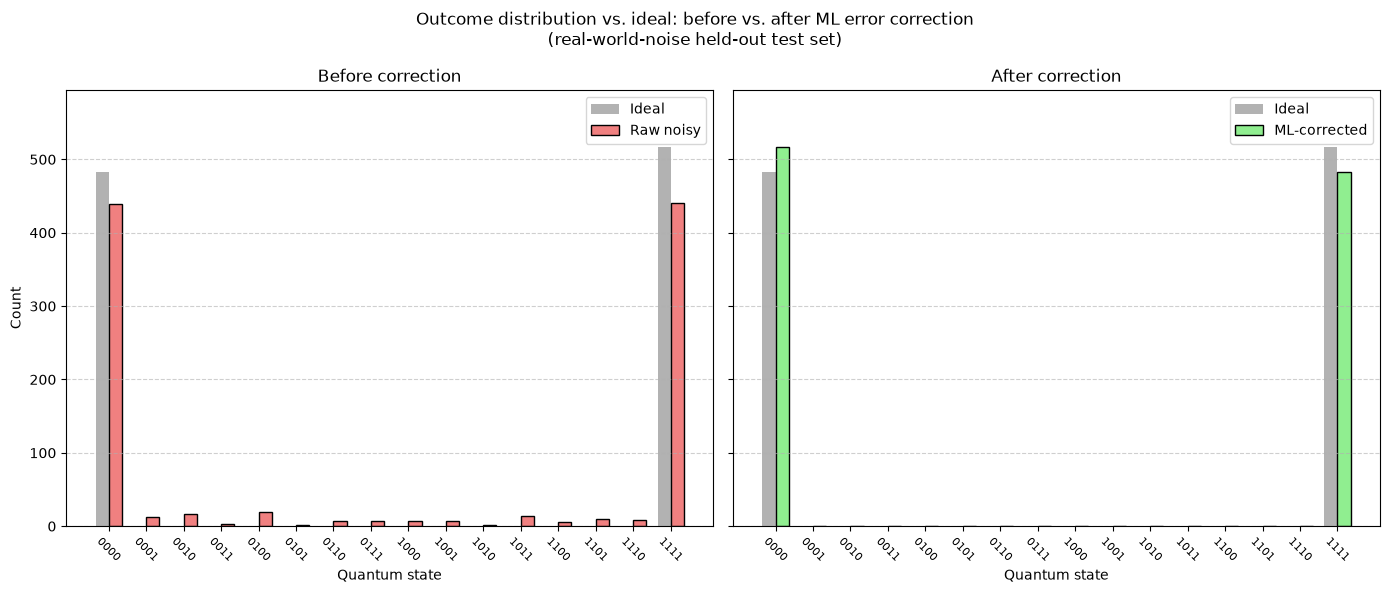

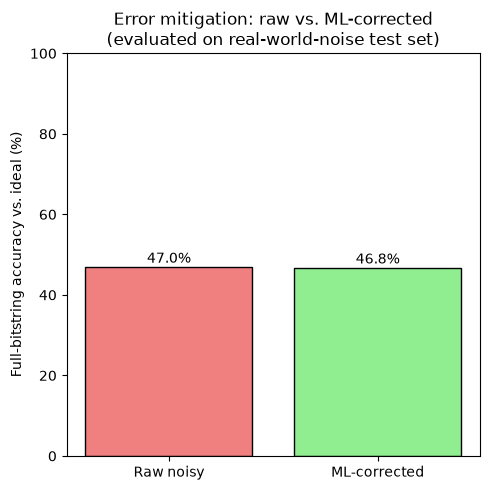

7 

Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...
Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...

Training samples: 2550  (holdout: 450, real-world test: 1000)
Training MLP error-mitigation model...

=== Real-world NISQ evaluation (held-out test set) ===
Raw noisy bitstring accuracy:       44.30%
Model-corrected bitstring accuracy: 50.90%
Improvement:                        +6.60 percentage points

  qubit 0: raw=50.80%  corrected=50.90%
  qubit 1: raw=51.30%  corrected=50.90%
  qubit 2: raw=51.50%  corrected=50.90%
  qubit 3: raw=50.50%  corrected=50.90%


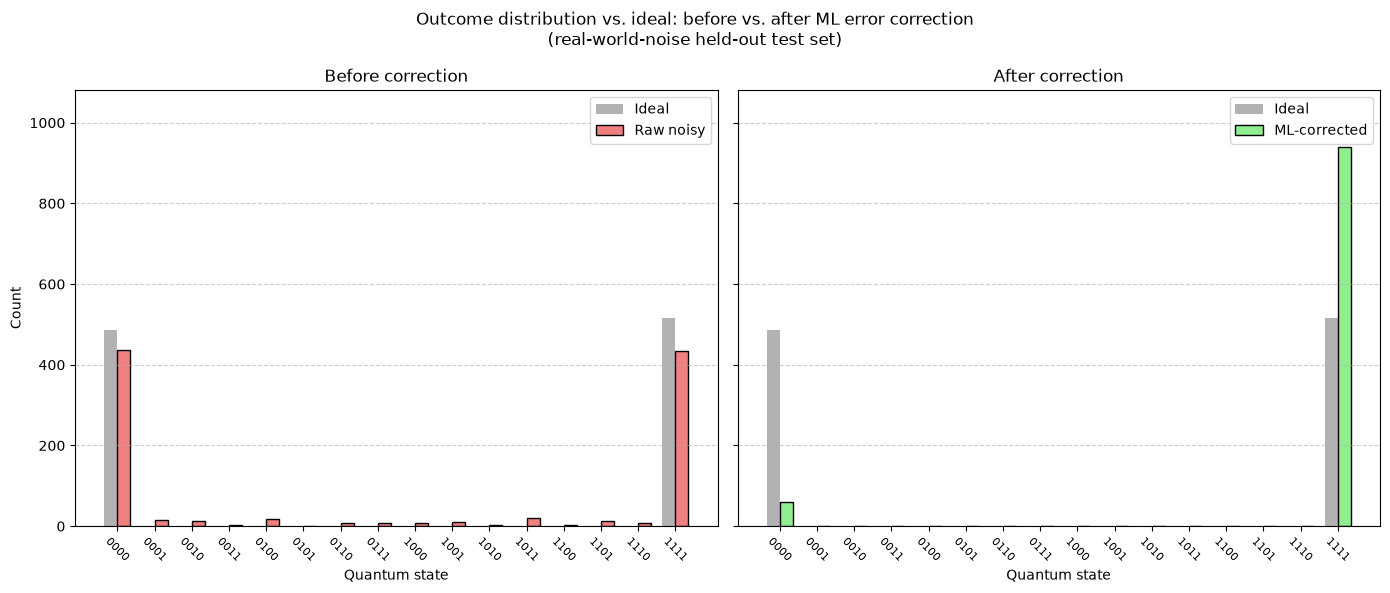

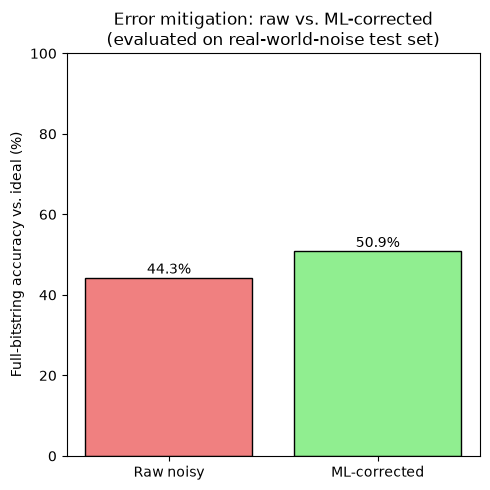

50 

Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...
Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...

Training samples: 2550  (holdout: 450, real-world test: 1000)
Training MLP error-mitigation model...

=== Real-world NISQ evaluation (held-out test set) ===
Raw noisy bitstring accuracy:       43.20%
Model-corrected bitstring accuracy: 50.50%
Improvement:                        +7.30 percentage points

  qubit 0: raw=49.30%  corrected=50.50%
  qubit 1: raw=49.70%  corrected=50.50%
  qubit 2: raw=48.60%  corrected=50.50%
  qubit 3: raw=48.50%  corrected=50.50%


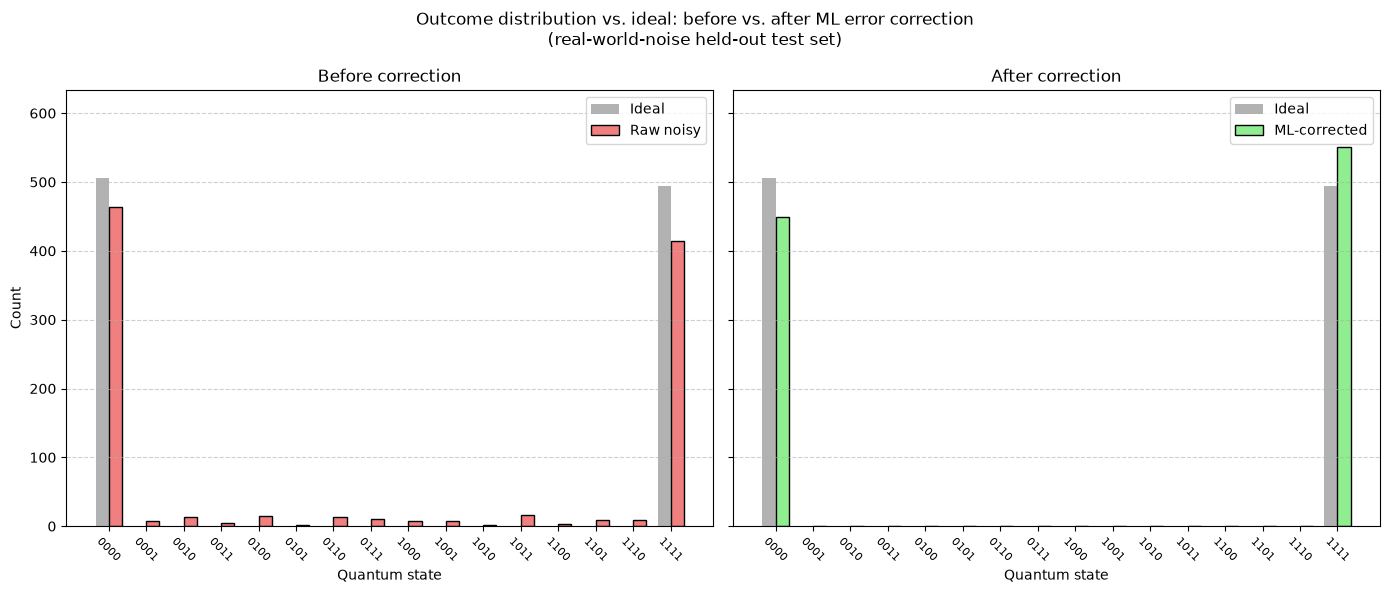

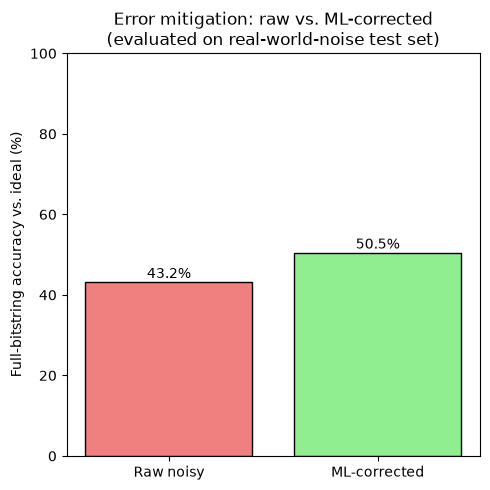

100 

Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...
Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...

Training samples: 2550  (holdout: 450, real-world test: 1000)
Training MLP error-mitigation model...

=== Real-world NISQ evaluation (held-out test set) ===
Raw noisy bitstring accuracy:       44.20%
Model-corrected bitstring accuracy: 51.20%
Improvement:                        +7.00 percentage points

  qubit 0: raw=50.00%  corrected=51.20%
  qubit 1: raw=49.90%  corrected=51.20%
  qubit 2: raw=50.20%  corrected=51.20%
  qubit 3: raw=50.90%  corrected=51.20%


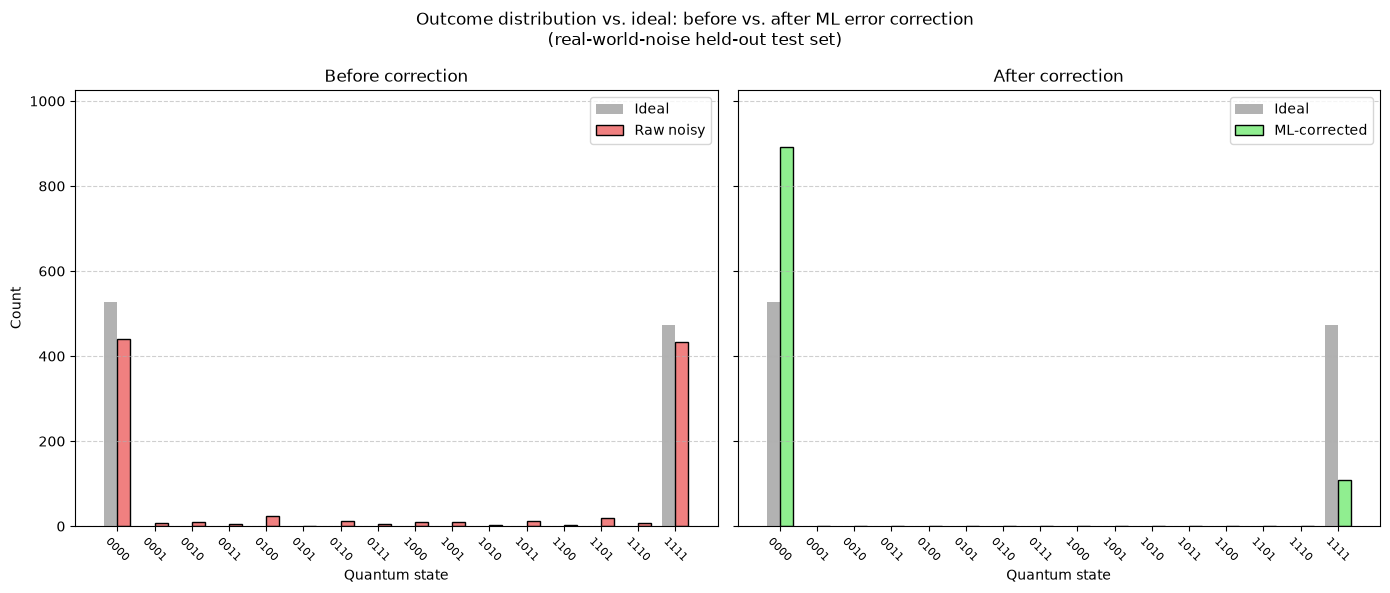

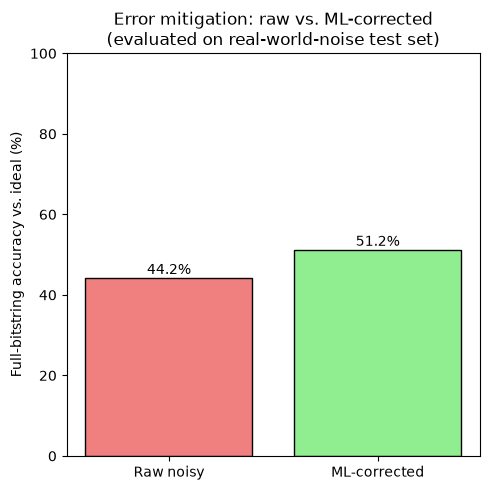

200 

Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...
Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...

Training samples: 2550  (holdout: 450, real-world test: 1000)
Training MLP error-mitigation model...

=== Real-world NISQ evaluation (held-out test set) ===
Raw noisy bitstring accuracy:       43.50%
Model-corrected bitstring accuracy: 49.70%
Improvement:                        +6.20 percentage points

  qubit 0: raw=50.70%  corrected=49.70%
  qubit 1: raw=50.30%  corrected=49.70%
  qubit 2: raw=50.20%  corrected=49.70%
  qubit 3: raw=49.80%  corrected=49.70%


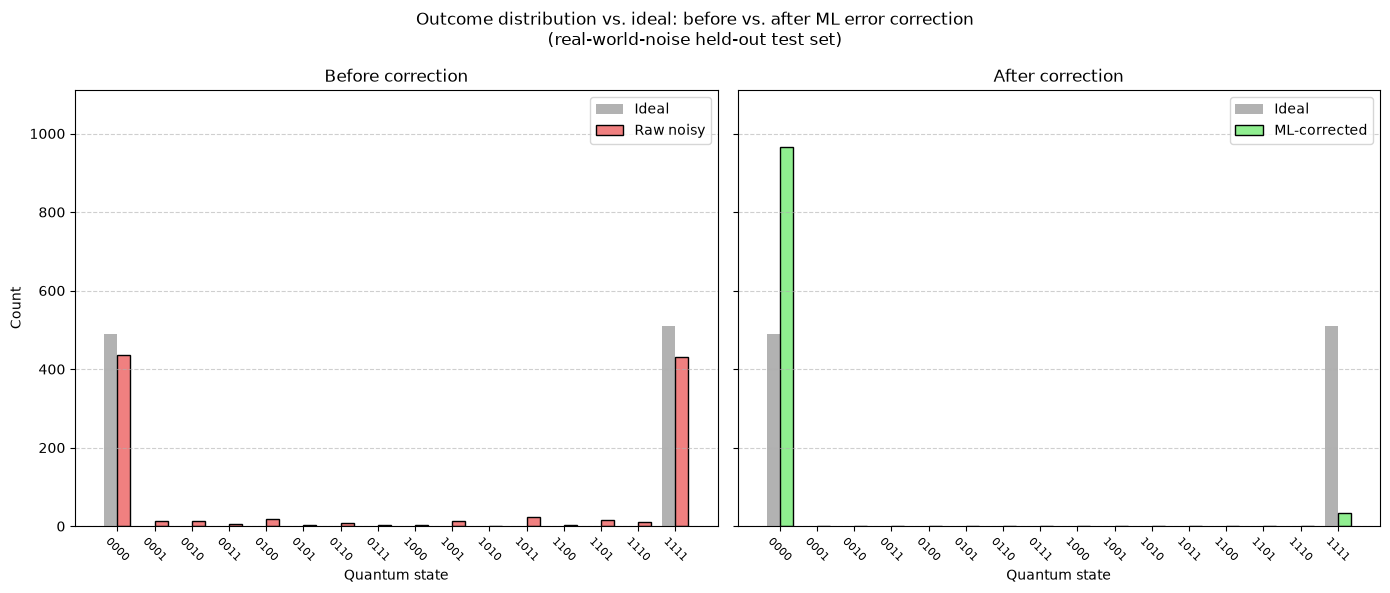

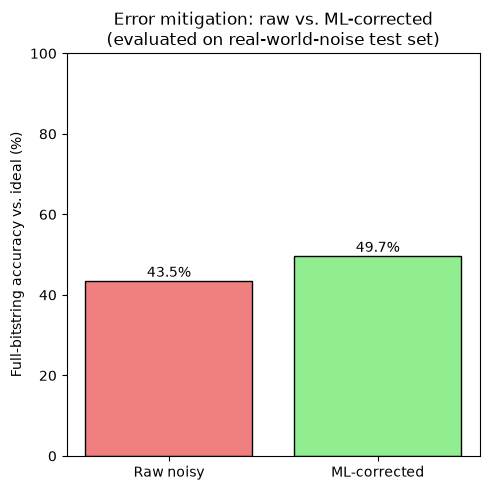

In [ ]:
choices = (1,7,50,100,200)
for num in range(len(choices)):
  RANDOM_SEED = choices[num]
  print(RANDOM_SEED,'\n')
  main()


['00', '01', '10', '11']
Sampled results:
Counter({'01': 1024})

Most common bitstring: 01
Found a match? True
Circuit for Grover's algorithm:
0: ─────────H───X───@───X───H───X───@───X───H───M('result')───
                    │               │           │
1: ─────────H───────@───H───X───────@───X───H───M─────────────
                    │               │
Ancilla: ───X───H───X───────────────X─────────────────────────


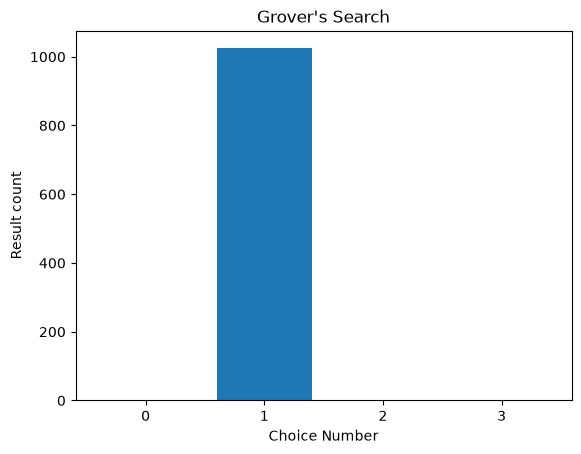

In [99]:
import math
number_choices = 4
correct_choice = 1

"Get qubits to use in the circuit for Grover's algorithm."
nqubits = 2

def generate_binary_strings(number_choices):
    n = int(math.log(number_choices,2))
    binary_strings = []
    for i in range(2**n):
        binary_string = bin(i)[2:].zfill(n)
        binary_strings.append(binary_string)
    return binary_strings

ls = generate_binary_strings(number_choices)
print(ls)

def make_oracle(qubits, ancilla, marked_bitstring):
    """Implements the function {f(x) = 1 if x == x', f(x) = 0 if x != x'}."""
    # For x' = (1, 1), the oracle is just a Toffoli gate.
    # For a general x', we negate the zero bits and implement a Toffoli.

    # Negate zero bits, if necessary.
    for (q, bit) in zip(qubits, marked_bitstring):
        if not bit:
            yield (cirq.X(q))
    # Do the Toffoli. change this to MCX for a generalized oracle
    #yield (cirq.TOFFOLI(qubits[0], qubits[1], ancilla))
    # controls = len(qubits) -1
    controls = len(qubits)
    mcx_gate = cirq.ControlledGate(sub_gate=cirq.X, num_controls=controls)
    yield (mcx_gate(*qubits, ancilla))

    # Negate zero bits, if necessary.
    for (q, bit) in zip(qubits, marked_bitstring):
        if not bit:
            yield (cirq.X(q))

def grover_iteration(qubits, ancilla, marked_bitstring, reps=1):
    """Performs one round of the Grover iteration."""
    circuit = cirq.Circuit()

    # Create an equal superposition over input qubits.
    circuit.append(cirq.H.on_each(*qubits))

    # Put the output qubit in the |-⟩ state.
    circuit.append([cirq.X(ancilla), cirq.H(ancilla)])
    for r in range(reps):
        # Query the oracle.
        # circuit.append(oracle)
        for (q, bit) in zip(qubits, marked_bitstring):
            if not bit:
                circuit.append([cirq.X(q)])
        # Do the Toffoli. change this to MCX for a generalized oracle
        #yield (cirq.TOFFOLI(qubits[0], qubits[1], ancilla))
        # controls = len(qubits) -1
        controls = len(qubits)
        mcx_gate = cirq.ControlledGate(sub_gate=cirq.X, num_controls=controls)
        circuit.append([mcx_gate(*qubits, ancilla)])

        # Negate zero bits, if necessary.
        for (q, bit) in zip(qubits, marked_bitstring):
            if not bit:
                circuit.append([cirq.X(q)])

        # Construct Grover operator.
        circuit.append(cirq.H.on_each(*qubits))
        circuit.append(cirq.X.on_each(*qubits))

        # circuit.append(cirq.H.on(qubits[-1]))
        controls = len(qubits)
        mcx_gate = cirq.ControlledGate(sub_gate=cirq.X, num_controls=controls)
        mcx_op = mcx_gate(*qubits, ancilla)
        circuit.append(mcx_op)
        # circuit.append(cirq.H.on(qubits[-1]))

        circuit.append(cirq.X.on_each(*qubits))
        circuit.append(cirq.H.on_each(*qubits))

    # Measure the input register.
    circuit.append(cirq.measure(*qubits, key="result"))

    return circuit

# Get qubit registers.
qubits = cirq.LineQubit.range(nqubits)
ancilla = cirq.NamedQubit('Ancilla')

def get_marked_bitstring(correct_choice, nqubits):
    binary_representation = list(bin(correct_choice)[2:])
    marked_bitstring = [eval(i) for i in binary_representation]
    desired_length = nqubits
    marked_bitstring = [0] * (desired_length - len(marked_bitstring)) + marked_bitstring
    return marked_bitstring

marked_bitstring = get_marked_bitstring(correct_choice, nqubits)

# Make oracle (black box)
oracle = make_oracle(qubits, ancilla, marked_bitstring)

# Embed the oracle into a quantum circuit implementing Grover's algorithm.
circuit = grover_iteration(qubits, ancilla, marked_bitstring)

"""Simulate the circuit for Grover's algorithm and check the output."""
# Helper function.
def bitstring(bits):
    return "".join(str(int(b)) for b in bits)

def binary_labels(num_qubits):
    return [bin(x)[2:].zfill(num_qubits) for x in range(2 ** num_qubits)]

# Sample from the circuit a couple times.
simulator = cirq.Simulator()
result = simulator.run(circuit, repetitions = 1024)

# Look at the sampled bitstrings.
frequencies = result.histogram(key="result", fold_func=bitstring)
print('Sampled results:\n{}'.format(frequencies))

# Check if we actually found the secret value.
most_common_bitstring = frequencies.most_common(1)[0][0]
print("\nMost common bitstring: {}".format(most_common_bitstring))
print("Found a match? {}".format(most_common_bitstring == bitstring(marked_bitstring)))

"""Create the circuit for Grover's algorithm."""

# Embed the oracle into a quantum circuit implementing Grover's algorithm.
circuit = grover_iteration(qubits, ancilla, marked_bitstring)
print("Circuit for Grover's algorithm:")
print(circuit)
# Sample from the circuit a couple times.
simulator = cirq.Simulator()
result = simulator.run(circuit, repetitions = 1024)

_ = cirq.plot_state_histogram(result, plt.subplot(), title = 'Grover\'s Search', xlabel = 'Choice Number', ylabel = 'Result count', tick_label=range(2**nqubits))
plt.show()

In [100]:
base_circuit = circuit

In [101]:
from __future__ import annotations

from dataclasses import dataclass

import cirq
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

LOUD_GATE_TYPES = (
    cirq.XPowGate,
    cirq.YPowGate,
    cirq.ZPowGate,
    cirq.HPowGate,
    cirq.CXPowGate,
    cirq.PhasedXPowGate,
)

# Fixes every source of randomness in this script (data generation, the
# train/holdout split, class balancing, and the classifier itself) so
# re-running produces the SAME result every time instead of a different
# one. Change this value if you deliberately want to test a different
# random realization.
RANDOM_SEED = 1


@dataclass
class NoiseConfig:
    name: str
    base_noise: float          # background error rate on idle qubits
    high_noise: float          # error rate on actively-driven qubits
    amplitude_damp_chance: float
    distance_between_qubits: float  # micrometers; smaller = stronger crosstalk


# "Low error percentage" baseline -- bulk of the training data.
LOW_NOISE_CONFIG = NoiseConfig(
    name="low_noise_baseline",
    base_noise=0.00005,
    high_noise=0.0002,
    amplitude_damp_chance=0.00002,
    distance_between_qubits=4,
)

# Higher, more realistic error rates -- mimics an actual NISQ device.
# Placeholder scale-up until calibrated against real hardware data.
REAL_WORLD_CONFIG = NoiseConfig(
    name="real_world_nisq",
    base_noise=0.02,
    high_noise=0.1,
    amplitude_damp_chance=0.001,
    distance_between_qubits=2,
)


# ================= Noise + crosstalk model (same as nisq_corrected.py) =================
def build_shot_circuit(original_circuit, all_qubits, config: NoiseConfig):
    """Builds one noisy shot circuit under the given NoiseConfig."""
    circuit = cirq.Circuit()
    for moment in original_circuit:
        circuit.append(moment)
        if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
            continue

        active_loud_qubits = {
            q for op in moment if isinstance(op.gate, LOUD_GATE_TYPES) for q in op.qubits
        }

        bit_flip_ops, depolarize_ops, flipped_qubit_indices = [], [], []
        for q_idx, q in enumerate(all_qubits):
            rate = config.high_noise if q in active_loud_qubits else config.base_noise
            bit_flip_ops.append(cirq.bit_flip(p=rate)(q))
            depolarize_ops.append(cirq.depolarize(p=rate)(q))
            if np.random.rand() < rate:
                flipped_qubit_indices.append(q_idx)

        #circuit.append(cirq.Moment(bit_flip_ops))
        circuit.append(cirq.Moment(depolarize_ops))
        circuit.append(cirq.Moment(cirq.amplitude_damp(config.amplitude_damp_chance)(q) for q in all_qubits))

        crosstalk_ops = []
        for q_idx, q in enumerate(all_qubits):
            if q_idx in flipped_qubit_indices:
                crosstalk_p = 1.0
            elif flipped_qubit_indices:
                distances = [
                    abs(q_idx - flipped_idx) * config.distance_between_qubits
                    for flipped_idx in flipped_qubit_indices
                ]
                shortest = max(min(distances), 1e-9)
                crosstalk_p = min(1.0, 1.0 / (shortest ** 2))
            else:
                crosstalk_p = 0.0
            crosstalk_ops.append(cirq.bit_flip(p=crosstalk_p)(q))
        circuit.append(cirq.Moment(crosstalk_ops))

    return circuit


# ================= Dataset generation =================
def generate_dataset(base_circuit, qubits, config: NoiseConfig, num_samples: int, ideal_simulator=None):
    """
    Returns (X, y):
      X = [base_noise, high_noise, amplitude_damp_chance, distance_between_qubits, *noisy_bitstring]
      y = ideal_bitstring (ground truth, from the noiseless circuit)

    Note: the bitstrings here have as many bits as are actually measured
    by `base_circuit` (its `cirq.measure(..., key='result')` operation),
    which is NOT necessarily the same as len(qubits) -- a circuit can use
    extra "helper" qubits internally that are never measured.
    """
    ideal_simulator = ideal_simulator or cirq.Simulator()
    noisy_simulator = cirq.Simulator()
    config_features = [
        config.base_noise,
        config.high_noise,
        config.amplitude_damp_chance,
        config.distance_between_qubits,
    ]

    X_rows, y_rows = [], []
    for _ in range(num_samples):
        shot_circuit = build_shot_circuit(base_circuit, qubits, config)
        noisy_bits = noisy_simulator.run(shot_circuit).measurements['result'][0]
        ideal_bits = ideal_simulator.run(base_circuit).measurements['result'][0]

        X_rows.append(config_features + list(noisy_bits))
        y_rows.append(list(ideal_bits))

    return np.array(X_rows, dtype=float), np.array(y_rows, dtype=float)


def bitstring_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Fraction of samples where EVERY bit matches the ideal bitstring."""
    return float(np.mean(np.all(y_true == y_pred, axis=1)))


def per_bit_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    """Per-qubit accuracy, useful for seeing which qubits are hardest to correct."""
    return np.mean(y_true == y_pred, axis=0)


def bits_to_state_indices(bit_rows: np.ndarray) -> np.ndarray:
    """Converts an (N, num_qubits) array of 0/1 rows into an (N,) array of integer state indices."""
    num_qubits = bit_rows.shape[1]
    weights = 2 ** np.arange(num_qubits - 1, -1, -1)
    return bit_rows.astype(int).dot(weights)


def state_indices_to_bits(state_indices: np.ndarray, num_qubits: int) -> np.ndarray:
    """Inverse of bits_to_state_indices: turns integer class labels back into 0/1 bit rows."""
    rows = [[int(b) for b in format(int(idx), f"0{num_qubits}b")] for idx in state_indices]
    return np.array(rows, dtype=float)


def balance_classes(X: np.ndarray, y_labels: np.ndarray, random_state: int = 0) -> tuple[np.ndarray, np.ndarray]:
    """
    Oversamples (with replacement) every class up to the size of the
    largest class, so the model can't learn "predict the more common
    outcome" as a shortcut. Without this, whichever ideal state happens
    to be slightly more frequent in a given (unseeded) data-generation
    run gets treated as the default answer, which is what causes the
    asymmetric over/under-correction between |0000> and |1111>.
    """
    rng = np.random.default_rng(random_state)
    unique_labels, counts = np.unique(y_labels, return_counts=True)
    target_count = counts.max()

    balanced_idx = []
    for label in unique_labels:
        idx_for_label = np.where(y_labels == label)[0]
        sampled_idx = rng.choice(idx_for_label, size=target_count, replace=True)
        balanced_idx.append(sampled_idx)
    balanced_idx = np.concatenate(balanced_idx)
    rng.shuffle(balanced_idx)

    return X[balanced_idx], y_labels[balanced_idx]


def plot_before_after_histograms(y_ideal: np.ndarray, y_noisy: np.ndarray, y_corrected: np.ndarray, num_qubits: int):
    """
    Side-by-side histograms over every computational basis state,
    comparing the ideal distribution against the raw noisy results
    (before correction) and the ML-corrected results (after correction).
    Same y-axis scale on both so the improvement is visually comparable.
    """
    num_states = 2 ** num_qubits
    labels = [format(i, f"0{num_qubits}b") for i in range(num_states)]

    ideal_counts = np.bincount(bits_to_state_indices(y_ideal), minlength=num_states)
    noisy_counts = np.bincount(bits_to_state_indices(y_noisy), minlength=num_states)
    corrected_counts = np.bincount(bits_to_state_indices(y_corrected), minlength=num_states)

    y_max = max(ideal_counts.max(), noisy_counts.max(), corrected_counts.max()) * 1.15
    x = np.arange(num_states)
    width = 0.35

    fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    ax_before.bar(x - width / 2, ideal_counts, width, label="Ideal", color="gray", alpha=0.6)
    ax_before.bar(x + width / 2, noisy_counts, width, label="Raw noisy", color="lightcoral", edgecolor="black")
    ax_before.set_title("Before correction")
    ax_before.set_xlabel("Quantum state")
    ax_before.set_ylabel("Count")
    ax_before.set_xticks(x)
    ax_before.set_xticklabels(labels, rotation=315, fontsize=8)
    ax_before.set_ylim(0, y_max)
    ax_before.legend()
    ax_before.grid(axis="y", linestyle="--", alpha=0.6)

    ax_after.bar(x - width / 2, ideal_counts, width, label="Ideal", color="gray", alpha=0.6)
    ax_after.bar(x + width / 2, corrected_counts, width, label="ML-corrected", color="lightgreen", edgecolor="black")
    ax_after.set_title("After correction")
    ax_after.set_xlabel("Quantum state")
    ax_after.set_xticks(x)
    ax_after.set_xticklabels(labels, rotation=315, fontsize=8)
    ax_after.legend()
    ax_after.grid(axis="y", linestyle="--", alpha=0.6)

    fig.suptitle("Outcome distribution vs. ideal: before vs. after ML error correction\n(real-world-noise held-out test set)")
    plt.tight_layout()
    plt.show()


# ================= Main training + evaluation pipeline =================
def main():
    np.random.seed(RANDOM_SEED)  # makes data generation, noise draws, and sampling reproducible



    print(f'your circuit \n\n{base_circuit}\n')
    ideal_sim = cirq.Simulator()

    # IMPORTANT FIX: `number_of_qubits` (3) is how many qubits the circuit
    # USES internally (qubit 2 is an unmeasured helper qubit), but the
    # `cirq.measure(...)` call above only measures qubits 0 and 1. Every
    # bitstring coming out of generate_dataset() is therefore only
    # `num_measured_qubits`-wide, NOT `number_of_qubits`-wide. Mixing the
    # two up is what caused:
    #   ValueError: operands could not be broadcast together with shapes (1000,2) (1000,3)
    # so we derive the measured-qubit count directly from the circuit and
    # use THAT (not number_of_qubits) everywhere a bitstring shape matters.
    measured_qubits = [
        q for op in base_circuit.all_operations()
        if isinstance(op.gate, cirq.MeasurementGate)
        for q in op.qubits
    ]
    num_measured_qubits = len(measured_qubits)

    print("Generating LOW-noise training data (clean baseline)...")
    X_low, y_low = generate_dataset(base_circuit, qubits, LOW_NOISE_CONFIG, num_samples=2400, ideal_simulator=ideal_sim)

    print("Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...")
    X_real_train, y_real_train = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, num_samples=600, ideal_simulator=ideal_sim)

    print("Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...")
    X_real_test, y_real_test = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, num_samples=1000, ideal_simulator=ideal_sim)

    # Training set: mostly low-noise (the "low error percentage" data),
    # with a smaller slice of real-world-noise data mixed in so the model
    # has at least seen the harder error regime it'll be evaluated on.
    X_train = np.vstack([X_low, X_real_train])
    y_train = np.vstack([y_low, y_real_train])
    # Stratify by joint outcome state so the train/holdout split preserves
    # whatever class balance the generated data has, instead of letting
    # an unstratified random split shift it further.
    y_train_labels_full = bits_to_state_indices(y_train)
    X_train, X_holdout, y_train, y_holdout = train_test_split(
        X_train, y_train, test_size=0.15, random_state=0, stratify=y_train_labels_full
    )

    print(f"\nTraining samples: {len(X_train)}  (holdout: {len(X_holdout)}, real-world test: {len(X_real_test)})")

    print("Training MLP error-mitigation model...")
    # IMPORTANT: this circuit's ideal outcomes are perfectly correlated
    # across qubits -- so instead of training independent per-bit
    # classifiers (which have no way to know the bits are linked, and
    # whose small individual biases compound into wildly overcorrecting
    # toward one state), we train ONE classifier over the joint outcome
    # state. This lets the model learn the correct *proportional*
    # asymmetry from the noise model (e.g. amplitude damping only ever
    # pulling 1->0) instead of an all-or-nothing collapse.
    y_train_labels = bits_to_state_indices(y_train)

    # Balance classes so no single outcome is treated as the "default"
    # answer just because it happened to be slightly more common in this
    # (unseeded) data-generation run.
    X_train_balanced, y_train_labels_balanced = balance_classes(X_train, y_train_labels)

    model = make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=0),
    )
    model.fit(X_train_balanced, y_train_labels_balanced)

    # --- Evaluate on the held-out real-world test set ---
    # FIX: slice off the last `num_measured_qubits` columns (not
    # `number_of_qubits`) since that's how many bits were actually measured.
    noisy_bits_test = X_real_test[:, -num_measured_qubits:]
    raw_acc = bitstring_accuracy(y_real_test, noisy_bits_test)

    corrected_labels_test = model.predict(X_real_test)
    # FIX: reconstruct bitstrings using num_measured_qubits, matching the
    # width of y_real_test.
    corrected_bits_test = state_indices_to_bits(corrected_labels_test, num_measured_qubits)
    corrected_acc = bitstring_accuracy(y_real_test, corrected_bits_test)

    raw_per_bit = per_bit_accuracy(y_real_test, noisy_bits_test)
    corrected_per_bit = per_bit_accuracy(y_real_test, corrected_bits_test)

    print("\n=== Real-world NISQ evaluation (held-out test set) ===")
    print(f"Raw noisy bitstring accuracy:       {raw_acc * 100:.2f}%")
    print(f"Model-corrected bitstring accuracy: {corrected_acc * 100:.2f}%")
    print(f"Improvement:                        {(corrected_acc - raw_acc) * 100:+.2f} percentage points\n")
    for i in range(num_measured_qubits):
        print(f"  qubit {i}: raw={raw_per_bit[i] * 100:5.2f}%  corrected={corrected_per_bit[i] * 100:5.2f}%")

    # --- Plots ---
    plot_before_after_histograms(y_real_test, noisy_bits_test, corrected_bits_test, num_measured_qubits)

    plt.figure(figsize=(5, 5))
    plt.bar(["Raw noisy", "ML-corrected"], [raw_acc * 100, corrected_acc * 100],
            color=["lightcoral", "lightgreen"], edgecolor="black")
    plt.ylabel("Full-bitstring accuracy vs. ideal (%)")
    plt.title("Error mitigation: raw vs. ML-corrected\n(evaluated on real-world-noise test set)")
    plt.ylim(0, 100)
    for i, v in enumerate([raw_acc * 100, corrected_acc * 100]):
        plt.text(i, v + 1, f"{v:.1f}%", ha="center")
    plt.tight_layout()
    plt.show()

your circuit 

0: ─────────H───X───@───X───H───X───@───X───H───M('result')───
                    │               │           │
1: ─────────H───────@───H───X───────@───X───H───M─────────────
                    │               │
Ancilla: ───X───H───X───────────────X─────────────────────────

Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...
Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...

Training samples: 2550  (holdout: 450, real-world test: 1000)
Training MLP error-mitigation model...

=== Real-world NISQ evaluation (held-out test set) ===
Raw noisy bitstring accuracy:       33.10%
Model-corrected bitstring accuracy: 100.00%
Improvement:                        +66.90 percentage points

  qubit 0: raw=57.20%  corrected=100.00%
  qubit 1: raw=56.00%  corrected=100.00%


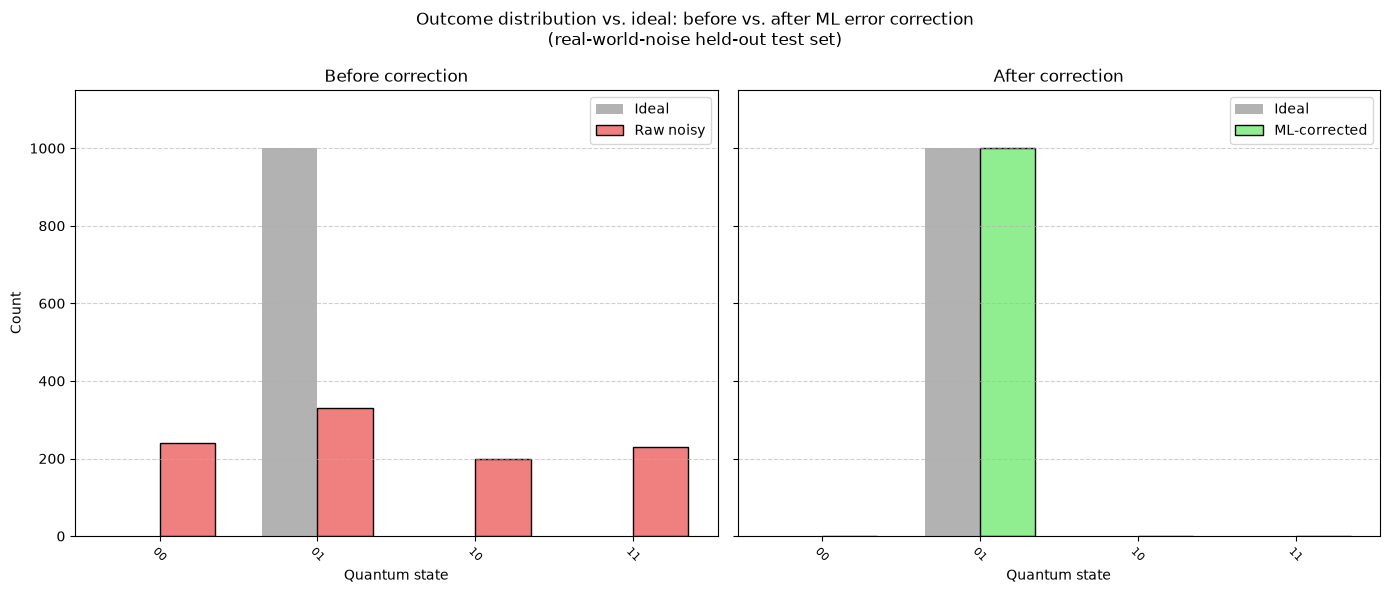

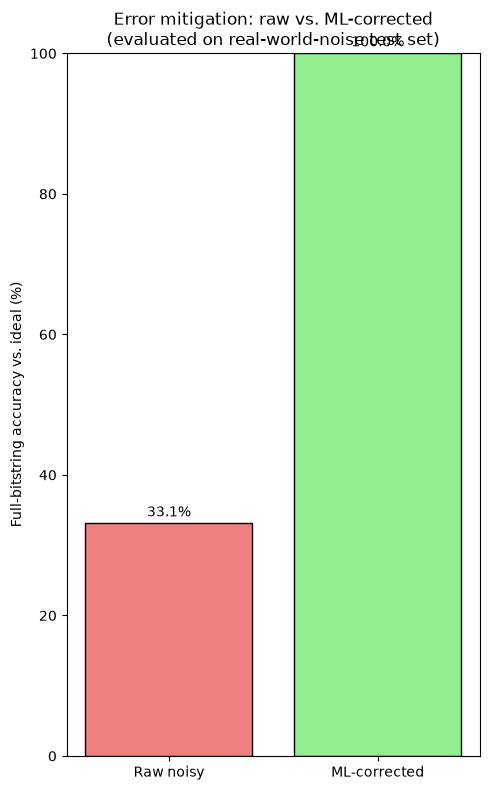

In [102]:
main()